<a href="https://colab.research.google.com/github/Brinthat/transformer_model/blob/main/breast_cancer_Report_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1.Data preprocessing -Converting csv data into report

In [ ]:
import pandas as pd

# Load and inspect the reports CSV
reports_path = '/content/drive/MyDrive/reports.csv'
reports_df = pd.read_csv(reports_path)
reports_df.head()

,CaseID,Image_filename,Mask_tumor_filename,Mask_other_filename,Pixel_size,Age,Tissue_composition,Signs,Symptoms,Shape,...,Echogenicity,Posterior_features,Halo,Calcifications,Skin_thickening,Interpretation,BIRADS,Verification,Diagnosis,Classification
0,1,case001.png,case001_tumor.png,NaN,0.007812,57,heterogeneous: predominantly fat,breast scar,family history of breast/ovarian cancer,irregular,...,heterogeneous,shadowing,no,no,yes,Breast scar (surgery)&Breast scar (radiotherapy),2,confirmed by follow-up care,not applicable,benign
1,2,case002.png,case002_tumor.png,NaN,0.006462,not available,homogeneous: fat,not available,not available,oval,...,hypoechoic,no,no,no,no,Dysplasia&Fibroadenoma,4b,confirmed by biopsy,Intramammary lymph node,benign
2,3,case003.png,case003_tumor.png,NaN,0.006944,56,heterogeneous: predominantly fat,no,nipple discharge,oval,...,hyperechoic,no,no,no,no,Duct filled with thick fluid&Intraductal papil...,4a,confirmed by biopsy,Usual ductal hyperplasia (UDH)&Pseudoangiomato...,benign
3,4,case004.png,case004_tumor.png,NaN,0.007812,43,homogeneous: fibroglandular,no,no,round,...,hypoechoic,no,no,no,no,Cyst filled with thick fluid,3,confirmed by follow-up care,not applicable,benign
4,5,case005.png,case005_tumor.png,NaN,0.007812,67,homogeneous: fat,nipple retraction&palpable,family history of breast/ovarian cancer,oval,...,complex cystic/solid,enhancement,no,no,no,Suspicion of malignancy&Intraductal papilloma,4b,confirmed by biopsy,Encapsulated papillary carcinoma&Ductal carcin...,malignant


In [ ]:
reports_df = reports_df.drop(columns=['Mask_tumor_filename','Mask_other_filename', 'Pixel_size'])
reports_df.head(2)

,CaseID,Image_filename,Age,Tissue_composition,Signs,Symptoms,Shape,Margin,Echogenicity,Posterior_features,Halo,Calcifications,Skin_thickening,Interpretation,BIRADS,Verification,Diagnosis,Classification
0,1,case001.png,57,heterogeneous: predominantly fat,breast scar,family history of breast/ovarian cancer,irregular,not circumscribed - indistinct,heterogeneous,shadowing,no,no,yes,Breast scar (surgery)&Breast scar (radiotherapy),2,confirmed by follow-up care,not applicable,benign
1,2,case002.png,not available,homogeneous: fat,not available,not available,oval,not circumscribed - indistinct,hypoechoic,no,no,no,no,Dysplasia&Fibroadenoma,4b,confirmed by biopsy,Intramammary lymph node,benign


In [ ]:
images_path = '/content/drive/MyDrive/BrEaST-Lesions_USG-images_and_masks'
reports_df['image_path'] = images_path + '/' + reports_df['Image_filename']

reports_df.head(2)

,CaseID,Image_filename,Age,Tissue_composition,Signs,Symptoms,Shape,Margin,Echogenicity,Posterior_features,Halo,Calcifications,Skin_thickening,Interpretation,BIRADS,Verification,Diagnosis,Classification,image_path
0,1,case001.png,57,heterogeneous: predominantly fat,breast scar,family history of breast/ovarian cancer,irregular,not circumscribed - indistinct,heterogeneous,shadowing,no,no,yes,Breast scar (surgery)&Breast scar (radiotherapy),2,confirmed by follow-up care,not applicable,benign,/content/drive/MyDrive/BrEaST-Lesions_USG-imag...
1,2,case002.png,not available,homogeneous: fat,not available,not available,oval,not circumscribed - indistinct,hypoechoic,no,no,no,no,Dysplasia&Fibroadenoma,4b,confirmed by biopsy,Intramammary lymph node,benign,/content/drive/MyDrive/BrEaST-Lesions_USG-imag...


**Data Preprocessing:**

**Text Columns:** Extract the relevant columns needed for generating the reports, such as Signs, Symptoms, Shape, Margin, Echogenicity, Posterior_features, Halo, Calcifications, Skin_thickening, and Interpretation.

**Target Column:** Use the Interpretation column as the target text for  report generation.

In [ ]:
# Preprocess the data into text descriptions and corresponding input_texts
def convert_to_text(row):
    # Create a natural language description of the input data
    input_text = f"Patient is {row['Age']} years old with tissue composition of {row['Tissue_composition']}. " \
                 f"Symptoms include {row['Signs']} and {row['Symptoms']}. Shape of the lesion is {row['Shape']}, " \
                 f"with margin {row['Margin']}, echogenicity {row['Echogenicity']}, and posterior features {row['Posterior_features']}."
    return input_text, row['Interpretation']

# Apply the conversion function to each row
reports_df['input_text'], reports_df['target_text'] = zip(*reports_df.apply(convert_to_text, axis=1))

In [ ]:
reports_df.head(2)

,CaseID,Image_filename,Age,Tissue_composition,Signs,Symptoms,Shape,Margin,Echogenicity,Posterior_features,...,Calcifications,Skin_thickening,Interpretation,BIRADS,Verification,Diagnosis,Classification,image_path,input_text,target_text
0,1,case001.png,57,heterogeneous: predominantly fat,breast scar,family history of breast/ovarian cancer,irregular,not circumscribed - indistinct,heterogeneous,shadowing,...,no,yes,Breast scar (surgery)&Breast scar (radiotherapy),2,confirmed by follow-up care,not applicable,benign,/content/drive/MyDrive/BrEaST-Lesions_USG-imag...,Patient is 57 years old with tissue compositio...,Breast scar (surgery)&Breast scar (radiotherapy)
1,2,case002.png,not available,homogeneous: fat,not available,not available,oval,not circumscribed - indistinct,hypoechoic,no,...,no,no,Dysplasia&Fibroadenoma,4b,confirmed by biopsy,Intramammary lymph node,benign,/content/drive/MyDrive/BrEaST-Lesions_USG-imag...,Patient is not available years old with tissue...,Dysplasia&Fibroadenoma


In [ ]:
reports_df = reports_df[['CaseID','input_text', 'target_text', 'image_path']]


In [ ]:
# Save the merged DataFrame to a CSV file
reports_df.to_csv('//content/drive/MyDrive/PYTHON NOTES/dataset.csv', index=False)


In [ ]:
df = pd.read_csv('//content/drive/MyDrive/PYTHON NOTES/dataset.csv')
df.head(2)

,CaseID,input_text,target_text,image_path
0,1,Patient is 57 years old with tissue compositio...,Breast scar (surgery)&Breast scar (radiotherapy),/content/drive/MyDrive/BrEaST-Lesions_USG-imag...
1,2,Patient is not available years old with tissue...,Dysplasia&Fibroadenoma,/content/drive/MyDrive/BrEaST-Lesions_USG-imag...


In [ ]:
print("Number of Unique Reports:", df['input_text'].nunique())
print("Average Length of Reports:", df['input_text'].str.len().mean())

Number of Unique Reports: 248
Average Length of Reports: 252.35546875


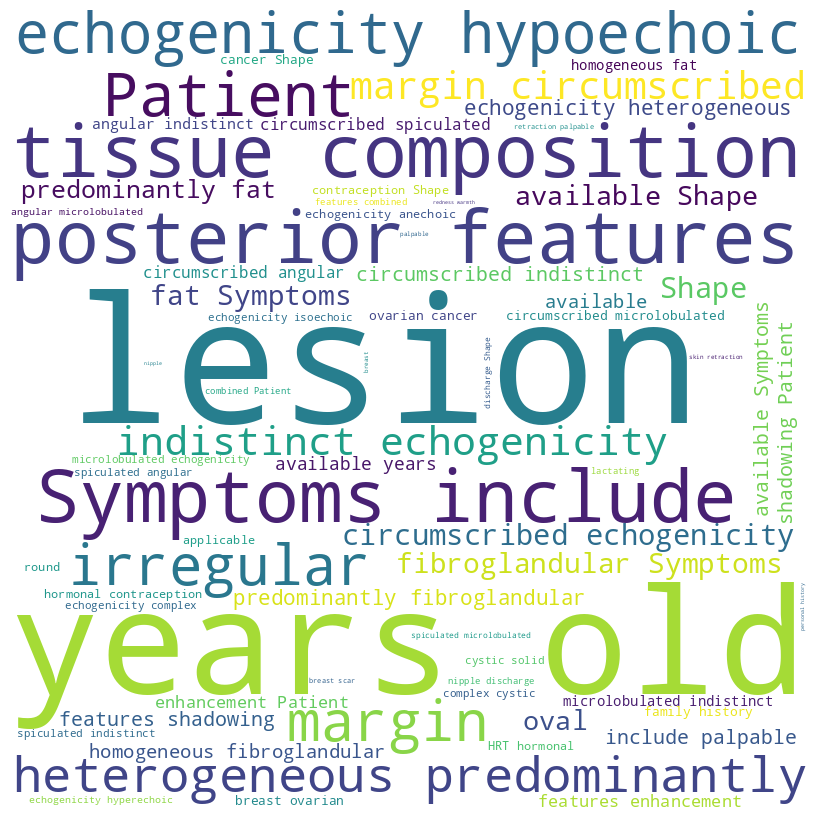

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

text = ' '.join(df['input_text'].dropna())
wordcloud = WordCloud(width=800, height=800, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


**Report Analysis**

Analyzing the distribution of report lengths before applying a transformer helps you understand the variability in your data, spot anomalies, and ensure that the model's input sequence lengths align with the data. This analysis informs decisions about tokenization, padding, truncation, and potential preprocessing strategies, ensuring efficient training and better model performance by tailoring the model to your dataset's characteristics. It also helps you anticipate resource needs and address any imbalances in report lengths for improved output quality.

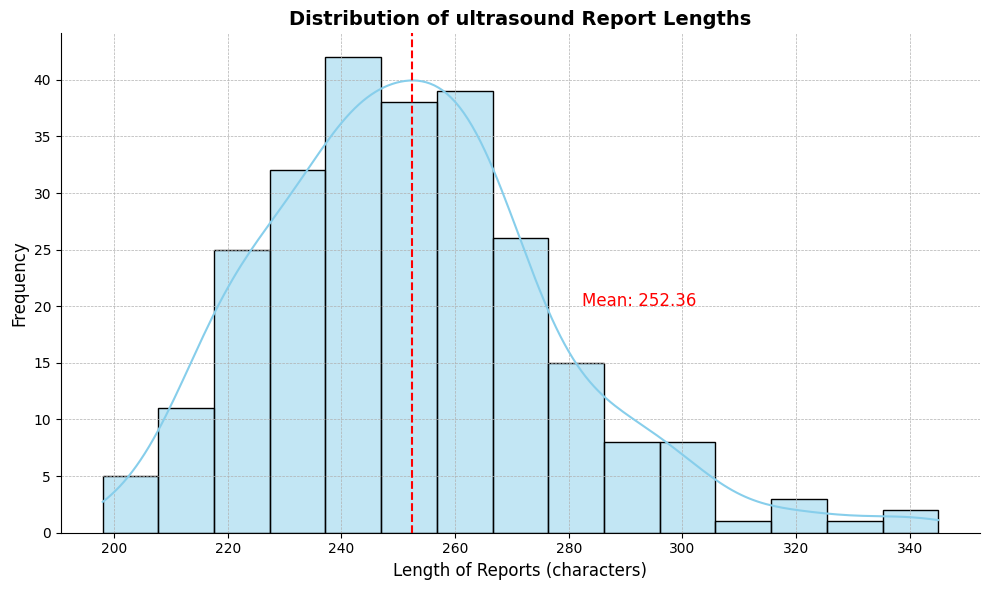

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Report Length Analysis
df['report_length'] = df['input_text'].str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df['report_length'], kde=True, color='skyblue')

# Adding grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Enhancing font and labels
plt.title('Distribution of ultrasound Report Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Length of Reports (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Statistical Information
mean_val = df['report_length'].mean()
plt.axvline(mean_val, color='red', linestyle='--')
plt.text(mean_val+30, 20, f'Mean: {mean_val:.2f}', color = 'red', fontsize=12)

# Customizing spines for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()


**CountVectorizer**

is used to convert text data into a numerical format by counting the frequency of each word in the corpus (Bag-of-Words model). It helps identify the most frequent words in the reports, giving insights into the key terms and patterns present in the dataset, which can be useful for feature extraction, data analysis, or report generation.

<ipython-input-35-777dcc52242b>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Frequency', data=top_df, palette='Blues_d')


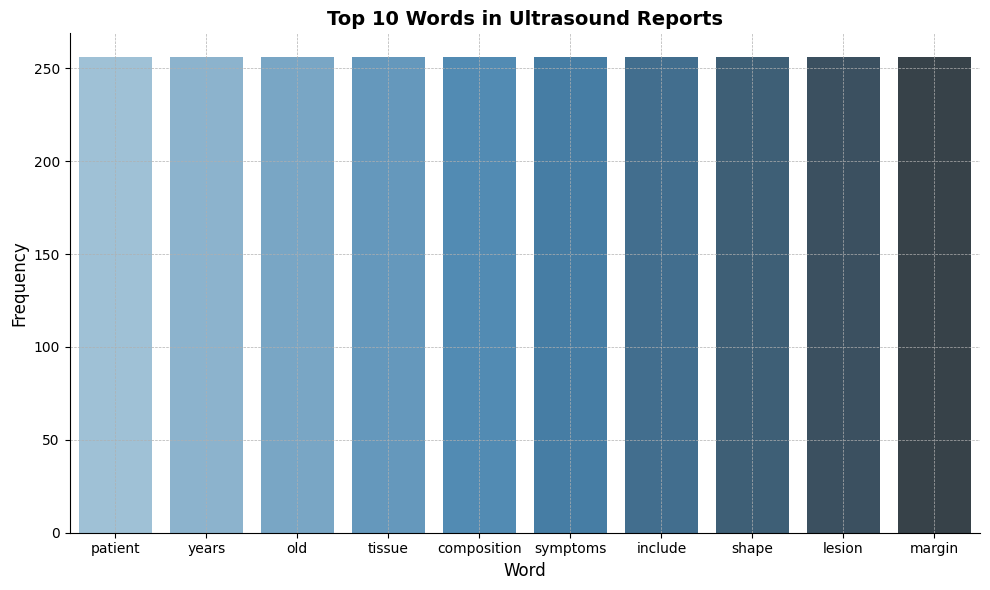

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words='english').fit(df['input_text'].dropna())
bag_of_words = vec.transform(df['input_text'].dropna())
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
top_words = words_freq[:10]
top_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

# Creating a more professional plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Word', y='Frequency', data=top_df, palette='Blues_d')

# Adding grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Enhancing font and labels
plt.title('Top 10 Words in Ultrasound Reports', fontsize=14, fontweight='bold')
plt.xlabel('Word', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Customizing spines for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation # Import LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(bag_of_words)

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic %d:" % (topic_idx))
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
display_topics(lda, vec.get_feature_names_out(), no_top_words)

Topic 0:
60 85 64 injury 40 48 78 53 51 21
Topic 1:
available symptoms composition echogenicity years patient posterior features margin old
Topic 2:
contraception hormonal hrt fibroglandular heterogeneous circumscribed include shape lesion tissue
Topic 3:
include shape lesion tissue old margin features patient posterior years
Topic 4:
breast cancer history ovarian family applicable enhancement scar homogeneous personal


In [ ]:
!pip install scikit-learn


**Bigrams** and **trigrams** capture word sequences and relationships, adding context that single words (unigrams) cannot. They improve text representation by considering common phrases and word dependencies, which helps in tasks like classification or report generation. This allows models to better understand patterns, context, and meaning in the data.

<ipython-input-38-0e295bfdeab9>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bi-gram', data=bi_grams_df, palette='Blues_d')


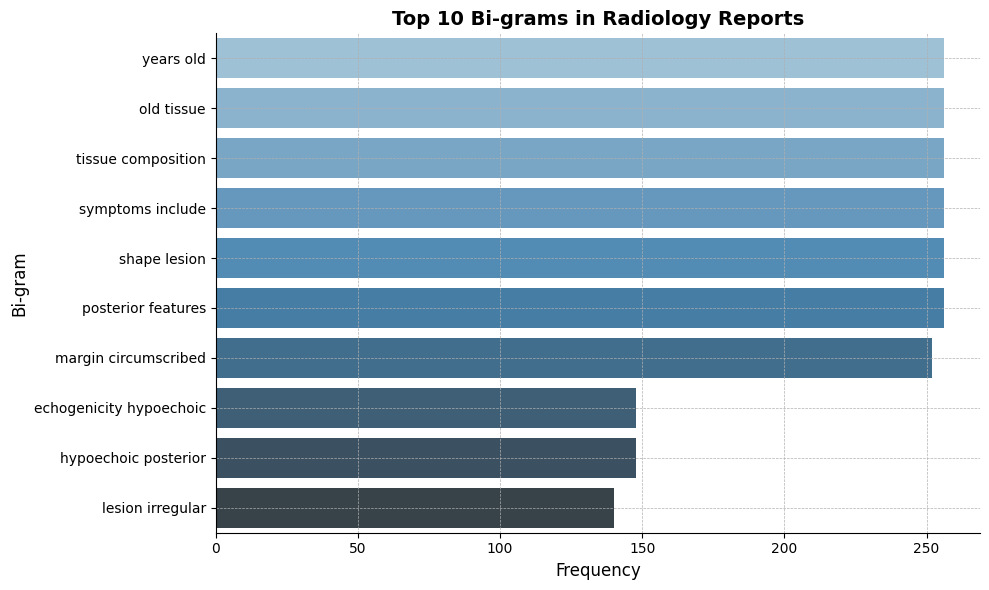

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.util import ngrams

# Function to extract n-grams
def get_top_ngrams(corpus, n=None, ngram=2):
    vec = CountVectorizer(ngram_range=(ngram, ngram), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Assuming df is your dataframe
top_bi_grams = get_top_ngrams(df['input_text'].dropna(), n=10, ngram=2)
bi_grams_df = pd.DataFrame(top_bi_grams, columns=['Bi-gram', 'Frequency'])

# Creating a more professional plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Bi-gram', data=bi_grams_df, palette='Blues_d')

# Adding grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Enhancing font and labels
plt.title('Top 10 Bi-grams in Radiology Reports', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Bi-gram', fontsize=12)

# Customizing spines for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()


<ipython-input-39-9109ffd5275f>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Tri-gram', data=tri_grams_df, palette='Blues_d')


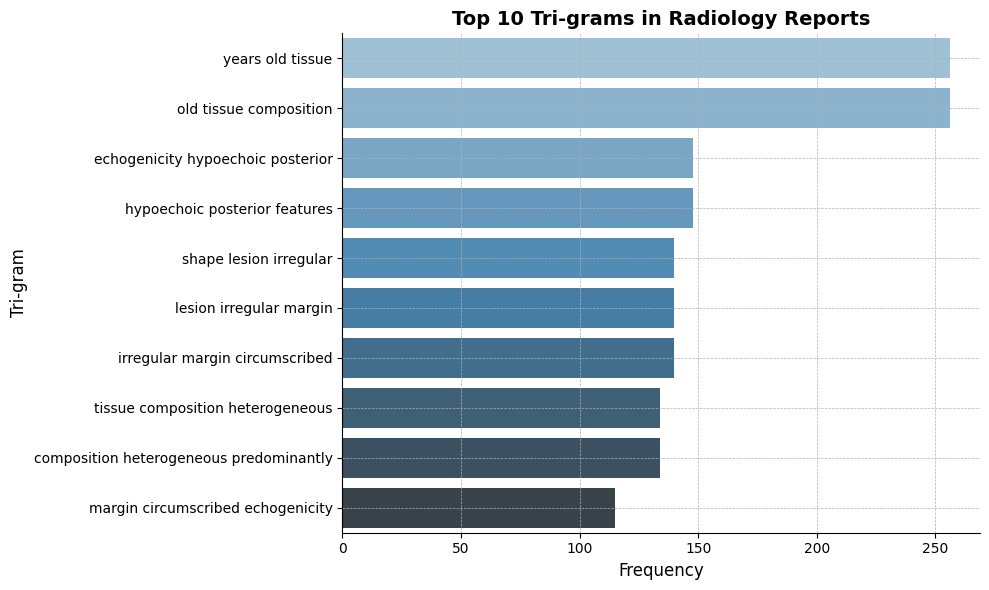

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Assuming get_top_ngrams function and df are defined as before
top_tri_grams = get_top_ngrams(df['input_text'].dropna(), n=10, ngram=3)
tri_grams_df = pd.DataFrame(top_tri_grams, columns=['Tri-gram', 'Frequency'])

# Creating a more professional plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Tri-gram', data=tri_grams_df, palette='Blues_d')

# Adding grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Enhancing font and labels
plt.title('Top 10 Tri-grams in Radiology Reports', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Tri-gram', fontsize=12)

# Customizing spines for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()


Named Entity Recognition (NER) to automatically identify and extract key entities, such as medical terms, conditions, and diagnoses, from the text.

In [ ]:
import spacy
from collections import Counter

# Load Spacy NLP model
nlp = spacy.load('en_core_web_sm')

# Sample text for NER
sample_text = df['input_text'].dropna().iloc[0]
doc = nlp(sample_text)

# Count entities
entity_counts = Counter([ent.label_ for ent in doc.ents])

# Visualize entities
spacy.displacy.render(doc, style='ent', jupyter=True)

# Print entity counts
print("Entity Counts:", entity_counts)


Entity Counts: Counter({'DATE': 1})


In [ ]:
pip install textstat

**Readability scores** measure how easy or difficult a piece of text is to understand.
Assessing Clarity: Medical reports often contain complex language. By calculating scores like Flesch Reading Ease and Gunning Fog Index, you can evaluate the clarity and readability of the reports. This helps ensure the reports are accessible to the intended audience, such as patients or medical professionals.

In [ ]:
import textstat

# Function to calculate readability scores
def readability_scores(text):
    return {
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
        "gunning_fog": textstat.gunning_fog(text)
    }

# Apply to sample text
sample_text = df['input_text'].dropna().iloc[0]
scores = readability_scores(sample_text)
print("Readability Scores:", scores)


Readability Scores: {'flesch_reading_ease': 15.98, 'gunning_fog': 15.46}


# 2. Data preprocessing - image data

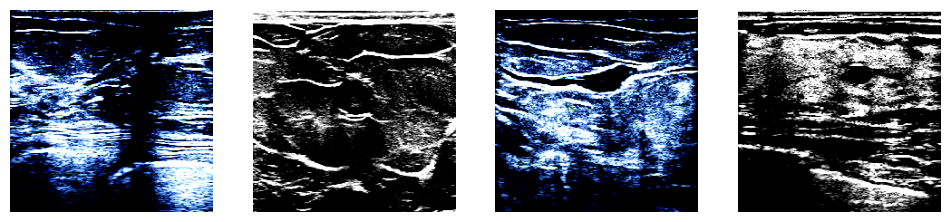

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array


# Define the preprocessing function
def preprocess_image(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image)
    image /= 255.0  # Normalize to [0, 1] range
    image = tf.image.per_image_standardization(image)  # Standardize image
    return image

# Define a custom dataset using tf.data
class ImageDataset:
    def __init__(self, dataframe, base_dir):
        self.dataframe = dataframe
        self.base_dir = base_dir

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.base_dir, self.dataframe.iloc[idx]['image_path'])
        image = preprocess_image(img_name)
        return image

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/PYTHON NOTES/dataset.csv')

# Initialize the dataset
dataset = ImageDataset(dataframe=data, base_dir='/content/drive/MyDrive/BrEaST-Lesions_USG-images_and_masks')

# Create a TensorFlow dataset from the ImageDataset class
def generator():
    for i in range(len(dataset)):
        yield dataset[i]

data_loader = tf.data.Dataset.from_generator(
    generator,
    output_signature=tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32)
)

data_loader = data_loader.batch(32).prefetch(tf.data.experimental.AUTOTUNE)

# Function to display a few images
def display_images(batch):
    plt.figure(figsize=(12, 8))
    for i in range(min(len(batch), 4)):  # Display 4 images
        ax = plt.subplot(1, 4, i + 1)
        plt.imshow(batch[i].numpy())
        plt.axis("off")
    plt.show()

# Get a batch of images and display them
images = next(iter(data_loader))
display_images(images)




# 3. Feature Extraction - ViT transformer

In [ ]:
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.4 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device: " , device)

Using device:  cpu


In [ ]:
import timm
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model = model.to(device)  # Move the model to GPU if available
model.eval()


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [ ]:
# Extract features
from tqdm.notebook import tqdm

features = []
with torch.no_grad():
    for batch in tqdm(data_loader, desc="Extracting features"):
        # Convert TensorFlow tensor to PyTorch tensor and move to device
        inputs = torch.from_numpy(batch.numpy()).permute(0, 3, 1, 2).to(device)
        outputs = model.forward_features(inputs)
        features.append(outputs.cpu().detach().numpy())
# Convert the list of arrays to a single array
features = np.concatenate(features, axis=0)

# Save the features to a file for further processing
np.save('/content/drive/MyDrive/features.npy', features)


Extracting features: 0it [00:00, ?it/s]

In [ ]:
# Now, `features` is a numpy array where each row corresponds to the features of an image
print(f"Extracted features for {features.shape[0]} images.")

Extracted features for 256 images.


In [ ]:
import numpy as np

# Load the features from the .npy file
feature_file_path = '/content/drive/MyDrive/features.npy'
features = np.load(feature_file_path)

# Check the shape of the loaded features
print("Shape of loaded features:", features.shape)


Shape of loaded features: (256, 197, 768)


In [ ]:
# Flatten the feature matrices
flattened_features = features.reshape(features.shape[0], -1)

# Now flattened_features is a 2D array
print("Shape of flattened features:", flattened_features.shape)


Shape of flattened features: (256, 151296)


<ipython-input-40-678576b4960e>:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], palette="viridis", legend="full")


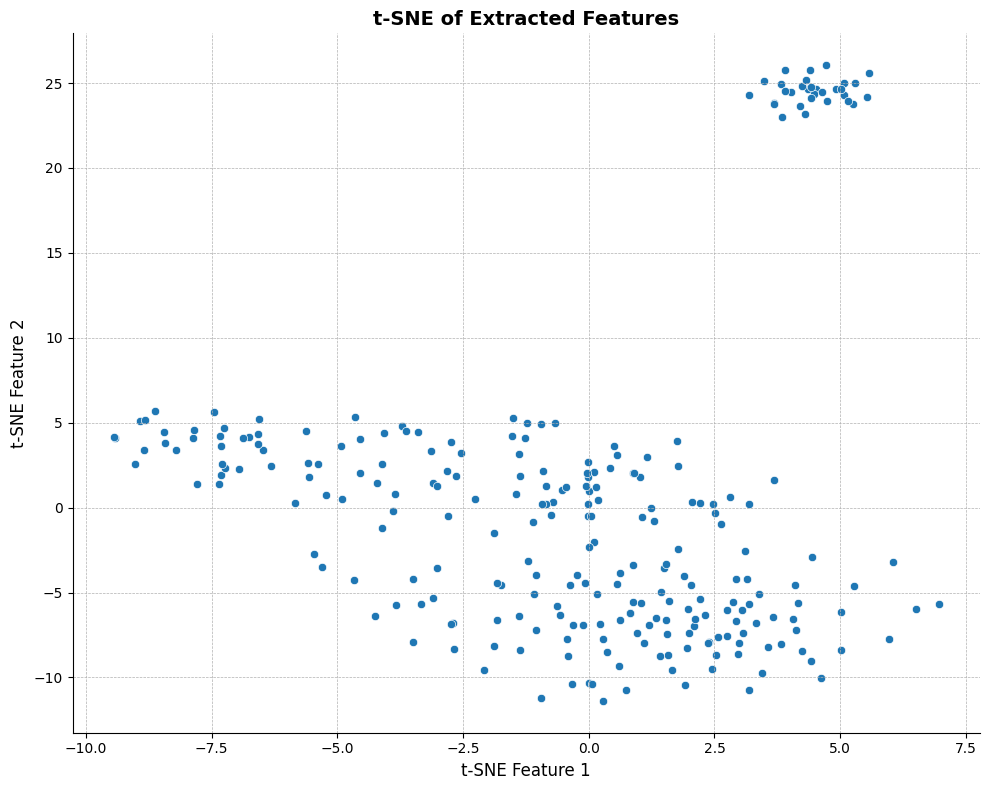

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Select a subset for t-SNE (use either flattened_features or pooled_features)
subset_of_features = flattened_features[:3500]

# subset_of_features is defined and contains the features you want to visualize
tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(subset_of_features)

# Creating a more professional plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], palette="viridis", legend="full")

# Adding grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Enhancing font and labels
plt.title('t-SNE of Extracted Features', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Feature 1', fontsize=12)
plt.ylabel('t-SNE Feature 2', fontsize=12)

# Customizing spines for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()


# 4.Tokenization

In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/PYTHON NOTES/dataset.csv')
# Assuming your DataFrame doesn't already have a unique identifier, you can use the default index
data['index'] = data.index
# Preprocessing function
def preprocess_text(text):
    # Replace 'nan' with an empty string and remove 'xxxx'
    text = text.replace('nan', '').replace('xxxx', '').replace('x-xxxx', '')

    # Convert to lowercase
    text = text.lower()

    # Replace newline characters with spaces, if any
    text = text.replace('\n', ' ')

    # Additional preprocessing as needed...

    return text



# Apply preprocessing
data['input_text'] = data['input_text'].astype(str).apply(preprocess_text)
data['target_text'] = data['target_text'].astype(str).apply(preprocess_text)

# Combine findings and impressions with index
data['combined_report'] = data['index'].astype(str) + " [IDX] " + data['input_text'] + " [SEP] " + data['target_text']

# Convert to list of strings
reports = data['combined_report'].tolist()

In [ ]:
reports

['0 [IDX] patient is 57 years old with tissue composition of heterogeneous: predomitly fat. symptoms include breast scar and family history of breast/ovarian cancer. shape of the lesion is irregular, with margin not circumscribed - indistinct, echogenicity heterogeneous, and posterior features shadowing. [SEP] breast scar (surgery)&breast scar (radiotherapy)',
 '1 [IDX] patient is not available years old with tissue composition of homogeneous: fat. symptoms include not available and not available. shape of the lesion is oval, with margin not circumscribed - indistinct, echogenicity hypoechoic, and posterior features no. [SEP] dysplasia&fibroadenoma',
 '2 [IDX] patient is 56 years old with tissue composition of heterogeneous: predomitly fat. symptoms include no and nipple discharge. shape of the lesion is oval, with margin circumscribed, echogenicity hyperechoic, and posterior features no. [SEP] duct filled with thick fluid&intraductal papilloma',
 '3 [IDX] patient is 43 years old with 

In [ ]:
# Save to a text file
with open('/content/drive/MyDrive/processed_reports.txt', 'w') as file:
    for report in reports:
        file.write(report + '\n')

In [ ]:
from transformers import GPT2Tokenizer

# Load the tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')

# Set the EOS token as the padding token
tokenizer.pad_token = tokenizer.eos_token

# Read the file
with open('/content/drive/MyDrive/processed_reports.txt', 'r') as file:
    reports = file.read().split('\n')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

In [ ]:
# Tokenize the text
inputs = tokenizer(reports, return_tensors='pt', max_length=218, truncation=True, padding='max_length')

In [ ]:
total_tokens = sum(len(input_ids) for input_ids in inputs['input_ids'])

print(f"Total number of tokens: {total_tokens}")

Total number of tokens: 56026


In [ ]:
from torch.utils.data import Dataset, DataLoader

class ReportsDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

# Create the dataset
dataset = ReportsDataset(inputs)

# Create a DataLoader
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)  # Adjust batch_size as per your GPU capacity

In [ ]:
from transformers import GPT2LMHeadModel, AdamW
import torch
# Load the model
model = GPT2LMHeadModel.from_pretrained("distilgpt2")

# Move model to GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

# Initialize optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
# Assuming 'inputs' is your tokenized data
inputs['labels'] = inputs['input_ids'].clone()

In [ ]:
from tqdm import tqdm

epochs = 10

# Training loop
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in tqdm(dataloader):
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}

        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss  # The model returns the loss when provided with labels

        # Check if loss is not None
        if loss is not None:
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        else:
            print("No loss to backpropagate.")

    # Calculate average loss
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch + 1} completed, Average Loss: {avg_loss:.4f}")

# Save the fine-tuned model
model.save_pretrained("/content/drive/MyDrive/gpt2")

100%|██████████| 33/33 [00:10<00:00,  3.04it/s]


Epoch 1 completed, Average Loss: 1.8081


100%|██████████| 33/33 [00:09<00:00,  3.42it/s]


Epoch 2 completed, Average Loss: 0.4568


100%|██████████| 33/33 [00:09<00:00,  3.38it/s]


...

Epoch 8 completed, Average Loss: 0.1043


100%|██████████| 33/33 [00:10<00:00,  3.13it/s]


Epoch 9 completed, Average Loss: 0.0993


100%|██████████| 33/33 [00:10<00:00,  3.08it/s]


Epoch 10 completed, Average Loss: 0.0968


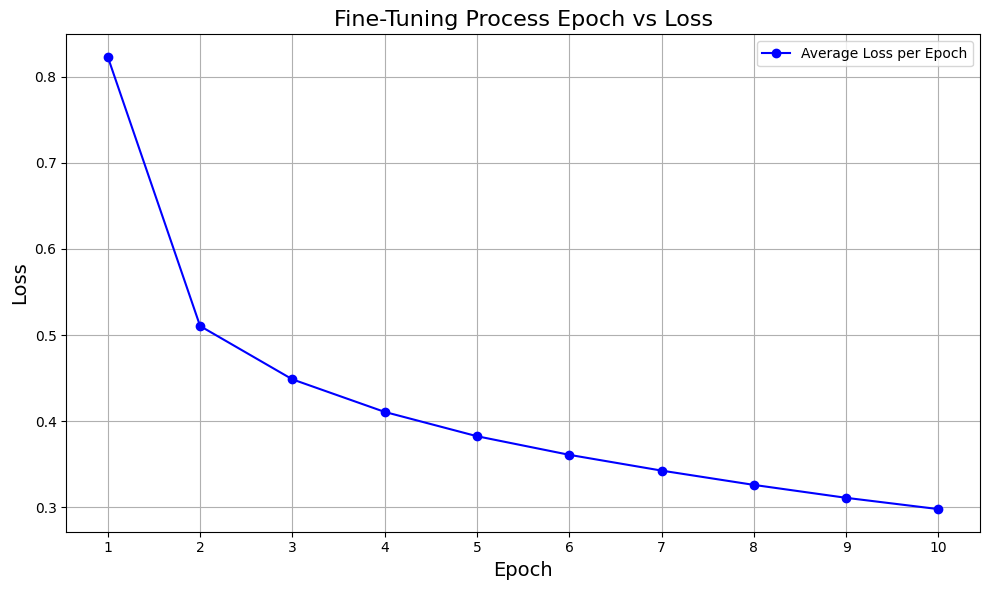

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have collected average loss per epoch in a list
average_losses = []  # Replace this with your actual list of average losses per epoch

average_losses = [0.8229, 0.5106, 0.4487, 0.4109, 0.3827, 0.3611, 0.3428, 0.3262, 0.3112, 0.2981]
epochs = range(1, len(average_losses) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, average_losses, marker='o', linestyle='-', color='b', label='Average Loss per Epoch')
plt.title('Fine-Tuning Process Epoch vs Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
model = GPT2LMHeadModel.from_pretrained("/content/drive/MyDrive/gpt2")
model.to(device)

# Compute perplexity over the validation dataset
total_loss = 0
model.eval()
with torch.no_grad():
    for batch in dataloader:
        # Ensure batch is on the correct device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch.get('attention_mask', None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
        total_loss += outputs.loss.item()

average_loss = total_loss / len(dataloader)
perplexity = torch.exp(torch.tensor(average_loss))

print(f"Perplexity: {perplexity}")

Perplexity: 1.0803240537643433


In [ ]:
import torch
import timm
from torchvision import transforms
from PIL import Image
from io import BytesIO

# Define the preprocessing transforms
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Function to load an image
def load_image(image_bytes):
    image = Image.open(BytesIO(image_bytes)).convert('RGB')
    image = preprocess(image)
    return image

# Function to extract features from a single image
def extract_features(image_bytes, model):
    image = load_image(image_bytes)
    image = image.unsqueeze(0)  # Add batch dimension

    with torch.no_grad():
        image = image.to(device)
        features = model.forward_features(image)
        return features.cpu().numpy()

# Load the pre-trained ViT model
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

# Load your image (replace with the path to your uploaded image)
uploaded_image_bytes = open('/content/drive/MyDrive/BrEaST-Lesions_USG-images_and_masks/case001.png', 'rb').read()

# Extract features from the uploaded image
extracted_features = extract_features(uploaded_image_bytes, model)
# Reshape the extracted features to match the dimensionality
# Change from (1, 197, 768) to (197, 768)
extracted_features = extracted_features.reshape(197, 768)

In [ ]:
extracted_features.shape

(197, 768)

In [ ]:
import numpy as np

# Load pre-extracted features
pre_extracted_features = np.load('/content/drive/MyDrive/features.npy')

In [ ]:
pre_extracted_features.shape

(256, 197, 768)

In [ ]:
# Reshape pre_extracted_features from (7466, 197, 768) to (7466, 197*768)
pre_extracted_features_flat = pre_extracted_features.reshape(pre_extracted_features.shape[0], -1)
pre_extracted_features_flat.shape

(256, 151296)

In [ ]:
from numpy.linalg import norm
def cosine_similarity(a, b):
    return np.dot(a, b.T) / (norm(a) * norm(b, axis=1))

In [ ]:
def find_most_similar_image(uploaded_features, dataset_features_flat):
    similarities = cosine_similarity(uploaded_features, dataset_features_flat)
    most_similar_index = np.argmax(similarities)
    max_similarity = similarities[most_similar_index]
    return most_similar_index, max_similarity

# Assuming extracted_features is reshaped to (197*768)
extracted_features_flat = extracted_features.reshape(-1)

# Find the most similar image
index_of_most_similar, similarity_score = find_most_similar_image(extracted_features_flat, pre_extracted_features_flat)

print(f"Most similar image index: {index_of_most_similar}, Similarity: {similarity_score}")

Most similar image index: 0, Similarity: 0.5735644698143005


In [ ]:
import pandas as pd
# Load the dataset to find the corresponding data
data = pd.read_csv('/content/drive/MyDrive/PYTHON NOTES/dataset.csv')

# Retrieve the data for the most similar image
similar_image_data = data.iloc[index_of_most_similar]

In [ ]:
similar_image_data

,0
CaseID,1
input_text,Patient is 57 years old with tissue compositio...
target_text,Breast scar (surgery)&Breast scar (radiotherapy)
image_path,/content/drive/MyDrive/BrEaST-Lesions_USG-imag...


In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load the fine-tuned model
model_path = "/content/drive/MyDrive/gpt2"
model = GPT2LMHeadModel.from_pretrained(model_path)

# Load the tokenizer and set the pad token
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
tokenizer.pad_token = tokenizer.eos_token


In [ ]:
# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/PYTHON NOTES/dataset.csv')

# Get the corresponding row for the most similar image
similar_image_data = data.iloc[index_of_most_similar]

# Extract relevant information (e.g., findings, impressions)
# You may adjust this based on how your model was fine-tuned
prompt_text = similar_image_data['target_text']


In [ ]:
prompt_text

'Breast scar (surgery)&Breast scar (radiotherapy)'

In [ ]:
# Tokenize the prompt text
input_ids = tokenizer.encode(prompt_text, return_tensors="pt")

# Generate text using the model
output_sequences = model.generate(
    input_ids=input_ids,
    max_length=218,  # Adjust as per your requirement
    temperature=0.5,
    top_k=50,
    top_p=0.95,
    repetition_penalty=1.2,
    do_sample=True,
    num_return_sequences=1
)

# Decode the generated text
generated_text = tokenizer.decode(output_sequences[0], skip_special_tokens=True)

print("Generated Report:\n", generated_text)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated Report:
 Breast scar (surgery)&Breast scar (radiotherapy)


In [ ]:
# Reference report (original report from the dataset)
reference_report = similar_image_data['input_text'] + " " + similar_image_data['target_text']

# Generated report (from your model)
generated_report = generated_text


In [ ]:
reference_report,generated_report

('Patient is 57 years old with tissue composition of heterogeneous: predominantly fat. Symptoms include breast scar and family history of breast/ovarian cancer. Shape of the lesion is irregular, with margin not circumscribed - indistinct, echogenicity heterogeneous, and posterior features shadowing. Breast scar (surgery)&Breast scar (radiotherapy)',
 'Breast scar (surgery)&Breast scar (radiotherapy)')

In [ ]:
pip install nltk rouge bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.tokenize import word_tokenize
from rouge import Rouge
from bert_score import score

# Tokenize the reports
reference_tokens = word_tokenize(reference_report.lower())
generated_tokens = word_tokenize(generated_report.lower())

# Calculate BLEU score
bleu_score = sentence_bleu([reference_tokens], generated_tokens)
print(f"BLEU Score: {bleu_score}")

# Calculate ROUGE scores
rouge = Rouge()
rouge_scores = rouge.get_scores(generated_report, reference_report)
print(f"ROUGE Scores: {rouge_scores}")

# Calculate BERTScores
P, R, F1 = score([generated_report], [reference_report], lang="en", verbose=True)
print(f"BERTScore Precision: {P.mean()}")
print(f"BERTScore Recall: {R.mean()}")
print(f"BERTScore F1 Score: {F1.mean()}")


BLEU Score: 0.013943702968593635
ROUGE Scores: [{'rouge-1': {'r': 0.10526315789473684, 'p': 1.0, 'f': 0.1904761887528345}, 'rouge-2': {'r': 0.09090909090909091, 'p': 1.0, 'f': 0.16666666513888892}, 'rouge-l': {'r': 0.10526315789473684, 'p': 1.0, 'f': 0.1904761887528345}}]


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.46 seconds, 2.19 sentences/sec
BERTScore Precision: 0.9372243285179138
BERTScore Recall: 0.8326242566108704
BERTScore F1 Score: 0.8818332552909851


In [ ]:
!pip install --upgrade nbconvert jupyter


In [ ]:
!ls /content

breast_cancer_Report_Generation.ipynb  drive  sample_data


In [ ]:
# convert ipynb to html and submit this HTML file
!jupyter nbconvert --to html "/content/breast_cancer_Report_Generation.ipynb"


[NbConvertApp] Converting notebook /content/breast_cancer_Report_Generation.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 8, in <module>
    sys.exit(main())
  File "/usr/local/lib/python3.10/dist-packages/jupyter_core/application.py", line 283, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.export_single_notebook(
  File "/usr/local/lib/python3.10/dist-packages/nbconvert/n